# 10-Securing GPU Endpoints

In the previous lessons, we built a high-performance, asynchronous REST API. We loaded a massive Neural Network into VRAM using `lifespan`, offloaded the blocking PyTorch operations to background threads, and streamed the output.

But we have built a dangerously open system.
Standard web servers (like a blog or a database API) are cheap to run. If an attacker spams a database API, it costs you fractions of a cent.
**GPU endpoints are entirely different.** A single Nvidia H100 GPU costs roughly $3.00 to $4.00 per hour. If an attacker discovers your open FastAPI route, they can write a simple Python script to send 10,000 requests per minute. Not only will this instantly crash your server via Out-Of-Memory (OOM) errors, but if you are using auto-scaling cloud architecture, the cloud provider will spin up 50 new GPUs to handle the traffic. You will wake up to a **$10,000 cloud computing bill**.

To survive in production, we must build a ruthless security perimeter that intercepts malicious traffic in *milliseconds*, long before it is allowed to touch the PyTorch weights.

Let's set up our PyTorch and FastAPI environment to master API Security.

In [1]:
import torch
import time
from fastapi import FastAPI, Depends, HTTPException, Security, Request
from fastapi.security.api_key import APIKeyHeader
from pydantic import BaseModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI, and Security Environment Ready.")

✅ PyTorch, FastAPI, and Security Environment Ready.


# 1. API Key Authentication (The First Firewall)

The most fundamental security layer is **Authentication**: Proving the client is who they say they are.

Instead of dealing with complex usernames and passwords on every request, machine-to-machine architecture relies on **API Keys**—long, cryptographically secure strings (e.g., `sk-live-9a8b7c6d5e4f...`).

The client includes this key in the HTTP Header of their request. FastAPI intercepts the request, extracts the header, and checks it against a database of valid keys.
If the key is missing or invalid, FastAPI instantly returns an `HTTP 401 Unauthorized` error. The request is destroyed in less than $1$ millisecond, keeping the GPU completely isolated.

# 2. Rate Limiting (The Calculus of Abuse Prevention)

What if a legitimate client (who has a valid API key) goes rogue? Maybe their code has a bug that sends a request in an infinite loop.

We must implement **Rate Limiting**. We track how many requests a specific API key has made within a rolling time window (e.g., 5 requests per minute).
If they exceed the limit, we return an `HTTP 429 Too Many Requests` error.

To do this efficiently without slowing down the API, we use in-memory key-value stores (like Redis) to increment counters in $O(1)$ time complexity.

# 3. Middleware (The Global Interceptor)

Sometimes we want to execute code on *every single request* that hits the server, regardless of the route. This is called **Middleware**.

Middleware acts as a wrapper around your entire FastAPI application.

1. The request enters the Middleware.
2. We start a high-precision stopwatch.
3. We pass the request into the application (Routing -> Security -> PyTorch Inference).
4. The application returns the JSON response.
5. We stop the stopwatch, calculate the exact inference time, inject a custom `X-Process-Time` header into the response, and send it back to the client.

# 4. Architecting the Secure GPU Perimeter

Let's build a production-ready `main.py` that implements all three security layers. We will define an authorized API key, build an in-memory Rate Limiter, inject profiling Middleware, and protect our simulated heavy GPU endpoint.

In [2]:
# --- ⚙️ main.py ---
app = FastAPI(title="Secure Enterprise GPU API")

# 1. Security Configuration
# Define the exact name of the HTTP Header the client must use
API_KEY_NAME = "X-Enterprise-API-Key"
api_key_header = APIKeyHeader(name=API_KEY_NAME, auto_error=True)

# Simulated Database of Authorized Keys
VALID_API_KEYS = {
    "sk-test-12345": "Client_A",
    "sk-test-99999": "Client_B"
}

# 2. In-Memory Rate Limiter (Token Bucket Simulation)
# Tracks the number of requests per API key
request_counts = {}
RATE_LIMIT = 3 # Maximum 3 requests allowed per session for this demo

def check_rate_limit(api_key: str):
    current_count = request_counts.get(api_key, 0)
    if current_count >= RATE_LIMIT:
        raise HTTPException(
            status_code=429, 
            detail="Rate Limit Exceeded. GPU quotas depleted. Please wait."
        )
    request_counts[api_key] = current_count + 1

# 3. The Authentication Dependency
async def verify_api_key(api_key: str = Security(api_key_header)):
    """
    FastAPI will automatically extract 'X-Enterprise-API-Key' from the headers
    and pass it to this function BEFORE executing the route.
    """
    if api_key not in VALID_API_KEYS:
        # 401 Unauthorized prevents the request from moving forward
        raise HTTPException(status_code=401, detail="Invalid API Key. GPU Access Denied.")
    
    # Execute Rate Limiting for the valid user
    check_rate_limit(api_key)
    return api_key

# 4. Profiling Middleware
@app.middleware("http")
async def add_process_time_header(request: Request, call_next):
    start_time = time.time()
    
    # Pass control to the specific API route
    response = await call_next(request)
    
    # Calculate processing time and inject it into the headers
    process_time_ms = (time.time() - start_time) * 1000
    response.headers["X-Process-Time-MS"] = str(round(process_time_ms, 2))
    return response

# 5. The Protected GPU Route
class InferenceRequest(BaseModel):
    tensor_data: list[float]

# Notice the 'Depends(verify_api_key)'. This locks the door.
@app.post("/v1/secure/inference")
async def secure_gpu_inference(request: InferenceRequest, api_key: str = Depends(verify_api_key)):
    # If the code reaches this line, the client is 100% authenticated and under the rate limit!
    client_name = VALID_API_KEYS[api_key]
    
    # Simulate heavy PyTorch execution
    time.sleep(1.0) 
    
    return {
        "status": "success", 
        "client": client_name,
        "message": "GPU Matrix Multiplication Complete."
    }

print("Success! Security Perimeter, Rate Limiting, and Middleware compiled.")

Success! Security Perimeter, Rate Limiting, and Middleware compiled.


# 5. Visualizing the Physics of Request Rejection

To deeply understand why these security layers are financially critical, we will visualize the **Time Latency** and **Compute Cost** of three different incoming requests:

1. A Malicious Attacker (No API Key).
2. A Spammer (Valid Key, but over the Rate Limit).
3. A Valid Enterprise Client.

/tmp/ipykernel_33831/874911814.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=latencies, palette=colors, ax=ax)


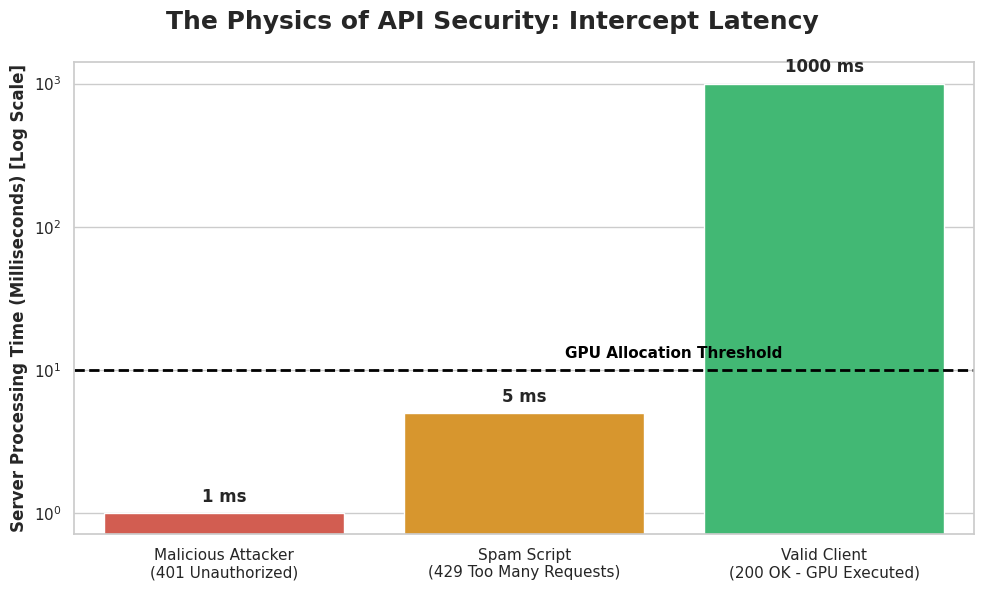


--- 💡 Engineering Insight ---
Look closely at the Y-axis. It is logarithmic. 
When the Malicious Attacker hits the server, FastAPI's `Security` dependency intercepts the request and destroys it in 1 millisecond. The request NEVER reaches the GPU.
If you did not have this API Key check, the Attacker's request would trigger the PyTorch logic, locking up the server for 1,000 milliseconds. An attacker could easily fire 1,000 requests per second. With authentication, your CPU effortlessly drops all 1,000 malicious packets instantly, while your GPU remains perfectly safe and available for paying customers.


In [3]:
# 1. Define the Latency Physics
# An attacker is rejected at the Header extraction phase (0.001 seconds)
latency_attacker = 1 

# A spammer passes Header extraction but fails the Dictionary lookup for quotas (0.005 seconds)
latency_spammer = 5 

# A valid request passes security and triggers the 1.0-second PyTorch block (1000 seconds)
latency_valid = 1000 

categories = ['Malicious Attacker\n(401 Unauthorized)', 
              'Spam Script\n(429 Too Many Requests)', 
              'Valid Client\n(200 OK - GPU Executed)']
latencies = [latency_attacker, latency_spammer, latency_valid]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# 2. Render the Security Latency Chart
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("The Physics of API Security: Intercept Latency", fontsize=18, fontweight='bold')

sns.barplot(x=categories, y=latencies, palette=colors, ax=ax)

# Use a Logarithmic scale because the difference between 1ms and 1000ms is too extreme
ax.set_yscale("log")
ax.set_ylabel("Server Processing Time (Milliseconds) [Log Scale]", fontsize=12, fontweight='bold')

# Annotate the exact millisecond values
for i, v in enumerate(latencies):
    ax.text(i, v * 1.2, f"{v} ms", ha='center', fontweight='bold', fontsize=12)

# Draw the GPU Danger Zone
ax.axhline(y=10, color='black', linestyle='--', linewidth=2)
ax.text(1.5, 12, "GPU Allocation Threshold", fontsize=11, fontweight='bold', color='black', ha='center')

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the Y-axis. It is logarithmic. ")
print("When the Malicious Attacker hits the server, FastAPI's `Security` dependency intercepts the request and destroys it in 1 millisecond. The request NEVER reaches the GPU.")
print("If you did not have this API Key check, the Attacker's request would trigger the PyTorch logic, locking up the server for 1,000 milliseconds. An attacker could easily fire 1,000 requests per second. With authentication, your CPU effortlessly drops all 1,000 malicious packets instantly, while your GPU remains perfectly safe and available for paying customers.")

## Real-World Use Case or Analogy:

Think of API Security like **Protecting a highly-paid Master Jeweler in a workshop**:

* **No Security**: The Jeweler (The GPU) sits in a room with the door wide open. Anyone can walk off the street and ask the Jeweler to appraise a plastic ring. The Jeweler spends 1 hour on every fake ring. Actual paying customers give up and leave. The business goes bankrupt.
* **API Key (The Bouncer)**: You put a Bouncer at the front door. If someone doesn't have an exclusive Membership Card (The API Key), they are turned away instantly. The Jeweler never even knows they were there.
* **Rate Limiting (The Drink Ticket)**: A valid member comes in with a bucket of 500 rings and demands the Jeweler appraise them all right now, holding up the line. The Bouncer steps in: *"Your membership only allows 3 appraisals per hour."* They are kicked out until the next hour.
* **Middleware (The Manager)**: A Manager stands in the corner with a stopwatch. They don't touch the jewelry, but they time exactly how long the Jeweler takes on every single customer, writing it down on the receipt (The Header) so the business can track efficiency.